# Support Vector Machine - Spam E-mail Classification


## 1. Import Data & Library

In [ ]:
# Instalasi library pihak ketiga (hanya dijalankan sekali di lingkungan seperti Google Colab)
!pip install Sastrawi     # Untuk pengolahan kata dasar bahasa Indonesia
!pip install wordcloud    # Untuk membuat visualisasi kumpulan kata


In [ ]:
!pip install nltk

In [ ]:

# Import library dasar untuk pengolahan data
import pandas as pd      # Untuk mengelola data dalam bentuk tabel (DataFrame)
import numpy as np       # Untuk perhitungan angka dan array
import warnings          # Untuk mengatur peringatan sistem
import re               # Untuk manipulasi teks (Regex)
import string           # Memanipulasi teks

# Mengabaikan pesan peringatan agar tampilan output lebih bersih
warnings.filterwarnings('ignore')

# Import alat pengolahan bahasa Indonesia (Sastrawi)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory           # Untuk mengubah kata berimbuhan ke kata dasar
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory # Untuk menghapus kata umum yang tidak penting

# Import library untuk visualisasi data
import matplotlib.pyplot as plt    # Untuk membuat grafik dasar
import seaborn as sns             # Untuk membuat tampilan grafik lebih cantik
from wordcloud import WordCloud    # Untuk membuat gambar awan kata

# Import alat Machine Learning (Scikit-Learn)
from sklearn.feature_extraction.text import TfidfVectorizer  # Mengubah teks menjadi angka (vektor) berdasarkan bobot kata
from sklearn.svm import LinearSVC                           # Algoritma klasifikasi (Support Vector Machine)
from sklearn.model_selection import StratifiedKFold         # Metode pembagian data untuk pengujian agar adil
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Indikator penilaian akurasi model
from sklearn.metrics import confusion_matrix, classification_report               # Laporan detail hasil  prediksi

# english part
import nltk
from nltk.corpus import stopwords
# import emoji
nltk.download('punkt')
nltk.download('wordnet')
from nltk.stem import PorterStemmer

# Import alat untuk menyimpan model
import joblib    # Untuk menyimpan model yang sudah dilatih agar bisa dipakai lagi nanti

# Pesan penutup proses persiapan
print("Library sudah siap, lanjut proses...")



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Library sudah siap, lanjut proses...


## 2. EDA (Exploratory Data Analysis)

In [ ]:
# Memberi tanda bahwa proses pembacaan data dimulai
print("Mulai dataset...")

# Membaca file CSV menggunakan library Pandas (df singkatan dari DataFrame)
df = pd.read_csv('spam.csv')

# Menampilkan jumlah total baris data yang ada di dalam file
print("Total data:", len(df))

# Menampilkan baris data untuk melihat struktur kolom dan isinya
print("\nShow Dataset:")
df


Mulai dataset...
Total data: 5572

Show Dataset:


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


Explore struktur kelas yaitu spam dan ham. Analisis Struktur Data

In [ ]:
# Menampilkan judul dan garis pembatas agar output terlihat rapi
print("DATASET SPAM E-MAIL")
print("-" * 40)

# Menampilkan dimensi data (jumlah baris, jumlah kolom)
print("Data Size:", df.shape)

# Menampilkan daftar nama kolom yang tersedia dalam file CSV
print("\nColumn:", df.columns.tolist())

# Mengecek tipe data setiap kolom (misal: object untuk teks, int64 untuk angka)
print("\nData type:")
print(df.dtypes)

# Menghitung jumlah data per Category (Spam vs Ham) sebelum diubah
print("\nLabel (Text):")
print(df['Category'].value_counts())

# PROSES ENCODING: Mengubah teks menjadi angka: spam jadi 1, ham (bukan spam) jadi 0
df['Category'] = df['Category'].map({'spam': 1, 'ham': 0})

# Menampilkan hasil perubahan untuk memastikan proses map berhasil
print("\nEncoded Label (Int):")
print(df['Category'].value_counts())


DATASET SPAM E-MAIL
----------------------------------------
Data Size: (5572, 2)

Column: ['Category', 'Message']

Data type:
Category    object
Message     object
dtype: object

Label (Text):
Category
ham     4825
spam     747
Name: count, dtype: int64

Encoded Label (Int):
Category
0    4825
1     747
Name: count, dtype: int64


## 3. Data Pra Pemrosesan


**1. Pengecekan Data Kosong (Handle missing Values)**

In [ ]:
# Menampilkan instruksi pengecekan data yang kosong
print("Checking Missing Value (before handling)\n")

# Menghitung jumlah sel kosong di setiap kolom
# .isnull() mengecek apakah data kosong, .sum() menjumlahkan total yang kosong
print(df.isnull().sum())

# Menghitung persentase data yang kosong
# Rumus: (jumlah kosong / total seluruh data) * 100
print("\nMissing Value Percentage(%):")
print((df.isnull().sum() / len(df)) * 100)


Checking Missing Value (before handling)

Category    0
Message     0
dtype: int64

Missing Value Percentage(%):
Category    0.0
Message     0.0
dtype: float64


**2. CLEANING**

*   Menghapus URL
*   Menghapus alamat email
*   Menghapus tag HTML
*   Menghapus tanda baca
*   Menghapus angka
*   Menghapus spasi berlebih

In [ ]:
# Membuat fungsi pembersih teks (Cleaning)
def cleaning_text(text):
    # Jika data kosong (NaN), kembalikan string kosong
    if pd.isna(text):
        return ""

    # Pastikan data dianggap sebagai teks (string)
    text = str(text)

    # Menghapus URL/Link website (http, https, www)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Menghapus alamat email
    text = re.sub(r'\S+@\S+', '', text)

    # Menghapus tag HTML (seperti <br>, <b>, dll)
    text = re.sub(r'<.*?>', '', text)

    # Menghapus angka
    text = re.sub(r'\d+', '', text)

    # Menghapus semua tanda baca (!, @, #, dst)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Menghapus karakter selain huruf (menghapus simbol aneh)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Menghapus huruf berulang yang berlebihan (contoh: 'horeeee' jadi 'horee')
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Menghapus spasi berlebih di awal, tengah, dan akhir teks
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Menjalankan proses cleaning
print("Start cleaning...")
# Membuat kolom baru bernama 'cleaning' hasil dari pemrosesan kolom 'Pesan'
df['Cleaned'] = df['Message'].apply(cleaning_text)

# Mengatur ulang urutan kolom agar lebih rapi dilihat
df = df[['Category', 'Message', 'Cleaned']]

# Menampilkan  untuk membandingkan Pesan asli vs Hasil cleaning
print("Data cleansing result:")
df


Start cleaning...
Data cleansing result:


,Category,Message,Cleaned
0,0,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in a wkly comp to win FA Cup final ...
3,0,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,This is the nd time we have tried contact u U ...
5568,0,Will ü b going to esplanade fr home?,Will b going to esplanade fr home
5569,0,"Pity, * was in mood for that. So...any other s...",Pity was in mood for that Soany other suggestions
5570,0,The guy did some bitching but I acted like i'd...,The guy did some bitching but I acted like id ...


**3. Case Folding**

In [ ]:
# Membuat fungsi untuk mengubah teks menjadi huruf kecil semua (Case Folding)
def case_folding(text):
    # Mengecek apakah input adalah teks (string)
    if isinstance(text, str):
        return text.lower() # Mengubah semua huruf menjadi kecil
    # Jika bukan teks (misal data kosong), kembalikan string kosong
    return ""

# Menjalankan fungsi case_folding pada kolom 'cleaning'
# Hasilnya disimpan di kolom baru bernama 'case_folding'
df['caseFolding'] = df['Cleaned'].apply(case_folding)

# Menampilkan 4 baris pertama untuk melihat perubahannya
print("Case folding (Results in lowercase):")
df


Case folding (Results in lowercase):


,Category,Message,Cleaned,case_folding,caseFolding
0,0,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,go until jurong point crazy available only in ...,go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,ok lar joking wif u oni,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in a wkly comp to win FA Cup final ...,free entry in a wkly comp to win fa cup final ...,free entry in a wkly comp to win fa cup final ...
3,0,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,u dun say so early hor u c already then say,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,nah i dont think he goes to usf he lives aroun...,nah i dont think he goes to usf he lives aroun...
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,This is the nd time we have tried contact u U ...,this is the nd time we have tried contact u u ...,this is the nd time we have tried contact u u ...
5568,0,Will ü b going to esplanade fr home?,Will b going to esplanade fr home,will b going to esplanade fr home,will b going to esplanade fr home
5569,0,"Pity, * was in mood for that. So...any other s...",Pity was in mood for that Soany other suggestions,pity was in mood for that soany other suggestions,pity was in mood for that soany other suggestions
5570,0,The guy did some bitching but I acted like i'd...,The guy did some bitching but I acted like id ...,the guy did some bitching but i acted like id ...,the guy did some bitching but i acted like id ...


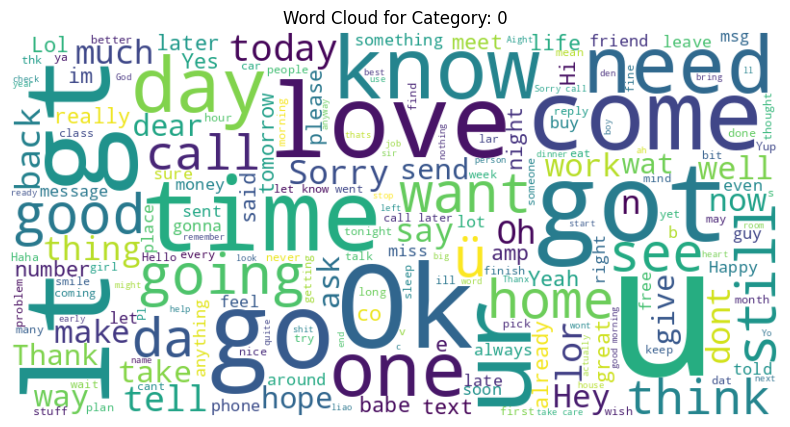

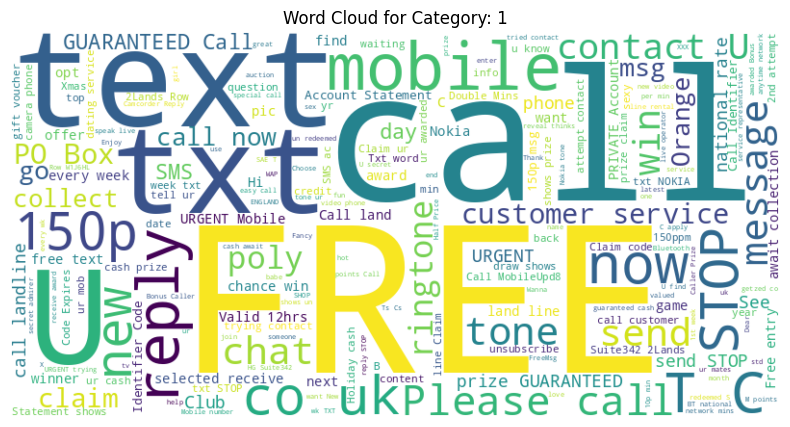

In [ ]:
# ISENG ISENGGGGG

# Iterate through unique categories
for category in df['Category'].unique():
    # Filter the DataFrame for the current category
    filtered_df = df[df['Category'] == category]

    # Concatenate all text data for the current category
    text = ' '.join(filtered_df['Message'])

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Plot the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for Category: {category}')
    plt.axis('off')
    plt.show()

**4. NORMALISASI**

In [ ]:
#  Define a dictionary of chat word mappings
chat_words = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA?": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don't care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "BFF": "Best friends forever",
    "CSL": "Can't stop laughing"
}

In [ ]:
# Function to replace chat words with their full forms
def replace_chat_words(text):
    words = text.split()
    for i, word in enumerate(words):
        if word.lower() in chat_words:
            words[i] = chat_words[word.lower()]
    return ' '.join(words)

# Apply replace_chat_words function to 'Text' column
df['Message'] = df['Message'].apply(replace_chat_words)

In [ ]:
Messages = df['Message']

In [ ]:
# # Mengambil kamus normalisasi umum dari sumber eksternal (GitHub)
# url = "https://raw.githubusercontent.com/evrintobing17/NormalisasiKata/master/colloquial-indonesian-lexicon.csv"
# normalization_data = pd.read_csv(url)

# # Mengubah data tersebut menjadi format 'Dictionary' (kunci: kata salah, nilai: kata benar)
# normalization_dict = dict(zip(normalization_data['slang'], normalization_data['formal']))

# # Menambahkan kamus buatan sendiri (Custom Dictionary) untuk kata-kata yang belum ada
# custom_dict = {
#     # Bahasa Gaul/Slang
#     "bro": "saudara", "gan": "saudara", "sis": "saudara", "nggak": "tidak", "gak": "tidak",
#     "ga": "tidak", "g": "tidak", "banget": "sangat", "bgt": "sangat", "gue": "saya",
#     "gw": "saya", "lo": "kamu", "lu": "kamu",

#     # Bahasa Tidak Baku / Singkatan
#     "gmn": "bagaimana", "jg": "juga", "dpt": "dapat", "aja": "saja", "udh": "sudah",
#     "tp": "tetapi", "sdh": "sudah", "skrg": "sekarang", "blm": "belum", "dgn": "dengan",
#     "utk": "untuk", "krn": "karena", "klo": "kalau", "kalo": "kalau", "msh": "masih",

#     # Istilah Khusus & Typo
#     "tf": "transfer", "trf": "transfer", "apps": "aplikasi", "trims": "terima kasih",
#     "makasih": "terima kasih", "moga": "semoga"
# }

# # Menggabungkan kamus dari GitHub dengan kamus buatan kita
# normalization_dict.update(custom_dict)

# Membuat fungsi untuk mengubah kata tidak baku menjadi baku



**5. TOKENISASI**

In [ ]:
# Memberikan informasi bahwa proses pemecahan kalimat dimulai
print("Tokenization...")

# Melakukan Tokenisasi menggunakan fungsi lambda
# x.split() berfungsi memotong kalimat berdasarkan spasi menjadi sebuah daftar kata (list)
# Contoh: "saya makan" menjadi ["saya", "makan"]
df['Tokenized'] = df['Message'].apply(lambda x: x.split())

# Menata ulang tampilan kolom untuk melihat perkembangan proses
# Kita tampilkan kolom Category, normalisasi (sebelum), dan tokenisasi (sesudah)
df_tampil = df[['Category', 'Message', 'Tokenized']]

# Menampilkan 4 baris pertama
df_tampil


Tokenization...


,Category,Message,Tokenized
0,0,"Go until jurong point, crazy.. Available only ...","[Go, until, jurong, point,, crazy.., Available..."
1,0,Ok lar... Joking wif u oni...,"[Ok, lar..., Joking, wif, u, oni...]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F..."
3,0,U dun say so early hor... U c already then say...,"[U, dun, say, so, early, hor..., U, c, already..."
4,0,"Nah I don't think he goes to usf, he lives aro...","[Nah, I, don't, think, he, goes, to, usf,, he,..."
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,"[This, is, the, 2nd, time, we, have, tried, 2,..."
5568,0,Will ü b going to esplanade fr home?,"[Will, ü, b, going, to, esplanade, fr, home?]"
5569,0,"Pity, * was in mood for that. So...any other s...","[Pity,, *, was, in, mood, for, that., So...any..."
5570,0,The guy did some bitching but I acted like i'd...,"[The, guy, did, some, bitching, but, I, acted,..."


**6. Stopword removal**

In [ ]:
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords corpus
nltk.download('stopwords')

# Get English stopwords from NLTK
stop_words = set(stopwords.words('english'))

# Function to remove stop words from text
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

# Apply remove_stopwords function to 'Text' column
df['Message'] = df['Message'].apply(remove_stopwords)
df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Category,Message,Cleaned,caseFolding,normalisasi,Tokenized,stopword_removal
0,0,"Go jurong point, crazy.. Available bugis n gre...",Go until jurong point crazy Available only in ...,go until jurong point crazy available only in ...,go until jurong point crazy available only in ...,"[Go, until, jurong, point,, crazy.., Available...","[Go, until, jurong, point,, crazy.., Available..."
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,ok lar joking wif u oni,ok lar joking wif u oni,"[Ok, lar..., Joking, wif, u, oni...]","[Ok, lar..., Joking, wif, u, oni...]"
2,1,Free entry 2 wkly comp win FA Cup final tkts 2...,Free entry in a wkly comp to win FA Cup final ...,free entry in a wkly comp to win fa cup final ...,free entry in a wkly comp to win fa cup final ...,"[Free, entry, in, 2, a, wkly, comp, to, win, F...","[Free, entry, in, 2, a, wkly, comp, to, win, F..."
3,0,U dun say early hor... U c already say...,U dun say so early hor U c already then say,u dun say so early hor u c already then say,u dun say so early hor u c already then say,"[U, dun, say, so, early, hor..., U, c, already...","[U, dun, say, so, early, hor..., U, c, already..."
4,0,"Nah think goes usf, lives around though",Nah I dont think he goes to usf he lives aroun...,nah i dont think he goes to usf he lives aroun...,nah i dont think he goes to usf he lives aroun...,"[Nah, I, don't, think, he, goes, to, usf,, he,...","[Nah, I, don't, think, he, goes, to, usf,, he,..."
...,...,...,...,...,...,...,...
5567,1,2nd time tried 2 contact u. U £750 Pound prize...,This is the nd time we have tried contact u U ...,this is the nd time we have tried contact u u ...,this is the nd time we have tried contact u u ...,"[This, is, the, 2nd, time, we, have, tried, 2,...","[This, is, the, 2nd, time, we, have, tried, 2,..."
5568,0,ü b going esplanade fr home?,Will b going to esplanade fr home,will b going to esplanade fr home,will b going to esplanade fr home,"[Will, ü, b, going, to, esplanade, fr, home?]","[Will, ü, b, going, to, esplanade, fr, home?]"
5569,0,"Pity, * mood that. So...any suggestions?",Pity was in mood for that Soany other suggestions,pity was in mood for that soany other suggestions,pity was in mood for that soany other suggestions,"[Pity,, *, was, in, mood, for, that., So...any...","[Pity,, *, was, in, mood, for, that., So...any..."
5570,0,guy bitching acted like interested buying some...,The guy did some bitching but I acted like id ...,the guy did some bitching but i acted like id ...,the guy did some bitching but i acted like id ...,"[The, guy, did, some, bitching, but, I, acted,...","[The, guy, did, some, bitching, but, I, acted,..."


**7. Stemming**
**Mengambil semua baris dari dataframe**

In [ ]:
# Initialize the Porter Stemmer
porter_stemmer = PorterStemmer()

# Apply stemming
df['Message_stemmed'] = df['Message'].apply(lambda x: ' '.join([porter_stemmer.stem(word) for word in x.split()]))

**8. REMOVE DUPLICATE / FINAL TEKS**


In [ ]:
# # Menggabungkan kembali list kata menjadi kalimat utuh (String)
# # Kalimat yang tadinya ['beli', 'promo', 'sekarang'] menjadi "beli promo sekarang"
# df['final_text'] = df['stemming'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))

# # Memastikan tipe data di kolom tersebut adalah teks (string)
# df['final_text'] = df['final_text'].astype(str)

# # Menghapus baris yang kosong (jika ada pesan yang isinya hilang setelah dibersihkan)
# df = df[df['final_text'].str.strip() != ""]

# # Menghapus data duplikat (pesan yang sama persis agar tidak mengganggu penilaian model)
# df = df.drop_duplicates(subset=['final_text'])

# # Mengatur ulang nomor urut data (index) agar rapi kembali dari 0
# df = df.reset_index(drop=True)

# # Menampilkan 4 baris pertama hasil akhir yang sudah sangat bersih
# print("Hasil Final Preprocessing (Siap masuk ke Machine Learning):")
# df[['Category', 'final_text']].head(15)

lkadfnlkdsvkn# 4. Penyeimbangan Data Balancing

In [ ]:
from sklearn.utils import resample

# 1. Menampilkan tanda dimulainya proses penyeimbangan data
print("Data Balancing...")
print("=" * 50)

# 2. Memastikan label Category berupa teks agar mudah difilter (spam='1', ham='0')
df['Category'] = df['Category'].astype(str)

# 3. Memisahkan data ke dalam dua kelompok: Spam dan Ham
df_spam = df[df['Category'] == '1']
df_ham = df[df['Category'] == '0']

# 4. Menampilkan jumlah data asli sebelum diseimbangkan
print("Sebelum balancing:")
print(df['Category'].value_counts())

# 5. Proses Resampling: Mengambil sampel sebanyak 50 untuk masing-masing Category
# Catatan: n_samples disesuaikan agar jumlah spam dan ham menjadi sama (seimbang)
df_spam_bal = resample(df_spam, replace=False, n_samples=200, random_state=42)
df_ham_bal = resample(df_ham, replace=False, n_samples=, random_state=42)

# 6. Menggabungkan kembali data spam dan ham yang sudah seimbang
df_balanced = pd.concat([df_spam_bal, df_ham_bal])

# 7. Mengacak (Shuffle) urutan data agar posisi spam dan ham tidak berurutan
# frac=1 artinya mengambil 100% data untuk diacak
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 8. Menampilkan hasil akhir setelah proses penyeimbangan
print("\nBalanced Data:")
print("New Data:", df_balanced.shape)
print(df_balanced['Category'].value_counts())


Data Balancing...
Sebelum balancing:
Category
0    4825
1     747
Name: count, dtype: int64

Balanced Data:
New Data: (400, 8)
Category
0    200
1    200
Name: count, dtype: int64


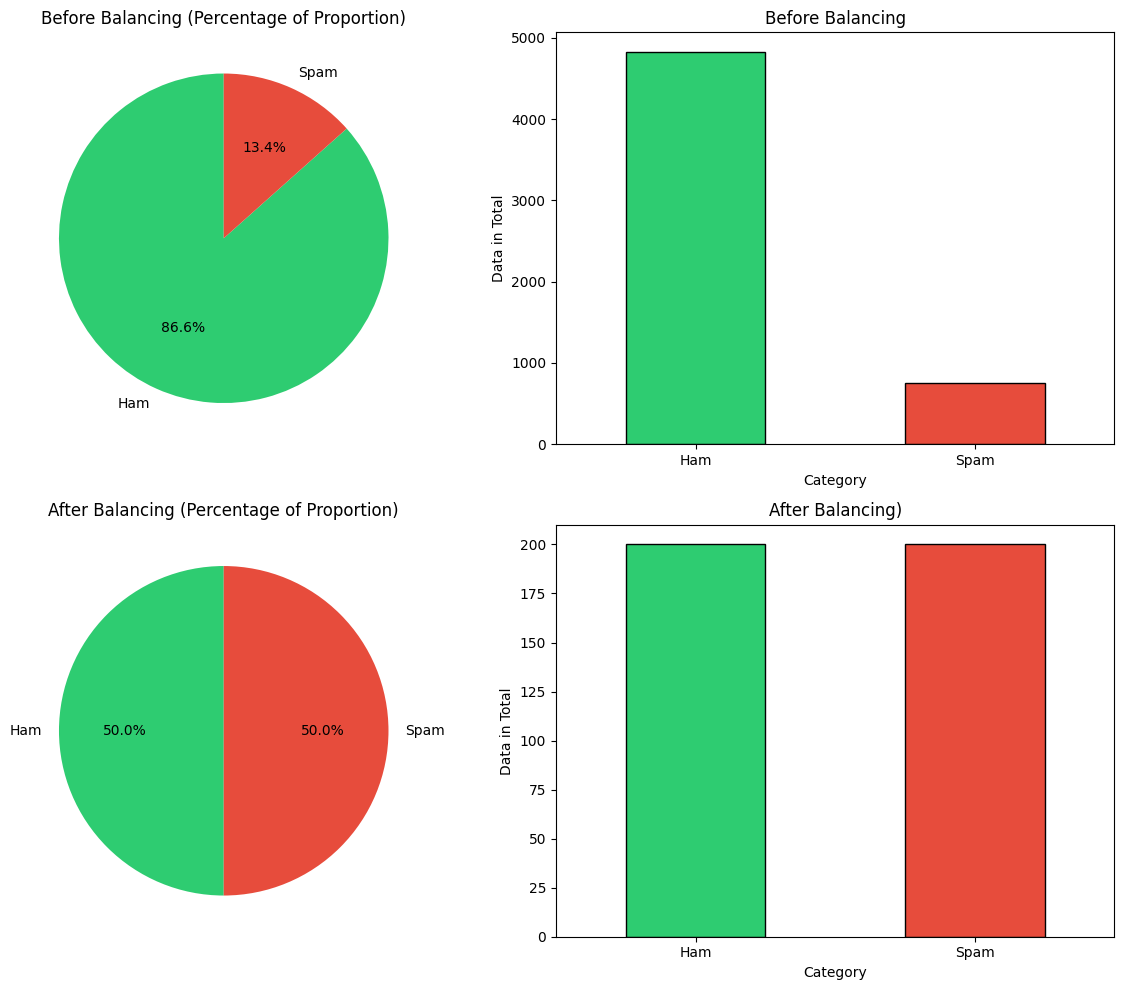

In [ ]:
import matplotlib.pyplot as plt

# Membuat kanvas/bingkai grafik dengan ukuran 2 baris dan 2 kolom
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Konfigurasi warna (Hijau untuk Ham, Merah untuk Spam)
colors = ['#2ecc71', '#e74c3c']
labels = ['Ham', 'Spam']

# --- BAGIAN ATAS: DATA SEBELUM BALANCING ---

# Menghitung jumlah data asli
sizes_before = df['Category'].value_counts().sort_index()

# Grafik Lingkaran (Pie Chart) - Kiri Atas
axes[0,0].pie(sizes_before, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Before Balancing (Percentage of Proportion)')

# Grafik Batang (Bar Chart) - Kanan Atas
sizes_before.plot(kind='bar', ax=axes[0,1], color=colors, edgecolor='black')
axes[0,1].set_title('Before Balancing')
axes[0,1].set_xticklabels(labels, rotation=0) # Mengatur label X agar tidak miring

# --- BAGIAN BAWAH: DATA SESUDAH BALANCING ---

# Menghitung jumlah data yang sudah diseimbangkan
sizes_after = df_balanced['Category'].value_counts().sort_index()

# Grafik Lingkaran (Pie Chart) - Kiri Bawah
axes[1,0].pie(sizes_after, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('After Balancing (Percentage of Proportion)')

# Grafik Batang (Bar Chart) - Kanan Bawah
sizes_after.plot(kind='bar', ax=axes[1,1], color=colors, edgecolor='black')
axes[1,1].set_title('After Balancing)')
axes[1,1].set_xticklabels(labels, rotation=0)

# Memberikan label pada sumbu grafik
for ax in [axes[0,1], axes[1,1]]:
    ax.set_xlabel("Category")
    ax.set_ylabel("Data in Total")

# Mengatur tata letak agar antar grafik tidak saling bertabrakan
plt.tight_layout()

# Menampilkan hasil visualisasi
plt.show()


## 5. Text Vectorization (TF-IDF)

TF-IDF (Term Frequency-Inverse Document Frequency) akan mengubah teks menjadi representasi numerik yang dapat diproses oleh model ML.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# 1. Menampilkan status proses
print("Membuat TF-IDF Vectorizer...")

# 2. Konfigurasi "Penerjemah" (Vectorizer)
# TF-IDF memberikan bobot pada kata: kata yang unik di satu dokumen tapi jarang di dokumen lain diberi bobot tinggi.
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,   # Mengambil maksimal 10.000 kata paling penting
    min_df=1,             # Kata minimal muncul 1 kali
    max_df=0.95,          # Abaikan kata yang muncul di lebih dari 95% data (terlalu umum)
    ngram_range=(1, 2),   # Mengambil kata tunggal (1) dan gabungan dua kata (2) contoh: "menang", "anda menang"
    lowercase=True        # Memastikan semua menjadi huruf kecil
)

# 3. Proses Transformasi (Fit & Transform)
# Mengubah kolom 'normalisasi' menjadi matriks angka (X)
X = tfidf_vectorizer.fit_transform(df_balanced['Message'])

# 4. Menyiapkan Label/Target (y)
# Mengubah kolom 'Category' menjadi angka bulat (Integer) 0 atau 1
y = df_balanced['Category'].astype(int)

# 5. Menampilkan hasil akhir
print("\nTF-IDF Done!")
# Shape menunjukkan: (Jumlah baris data, Jumlah fitur/kata unik yang ditemukan)
print("Matrix Size (Shape):", X.shape)


Membuat TF-IDF Vectorizer...

TF-IDF Done!
Matrix Size (Shape): (400, 5980)


## 6. Pengujian Model (K-Fold Cross Validation)
Manual split

*   Manual split
*   Validasi proporsi
* Klasifikasi




In [ ]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd

# 1. Menampilkan judul proses
print("Data splitting 5-Fold Cross Validation...")
print("=" * 50)

# 2. Menyiapkan "Mesin Pemotong" Data (StratifiedKFold)
# n_splits=5 artinya data akan dibagi menjadi 5 bagian/lipatan (fold)
# Stratified memastikan persentase label di setiap bagian tetap seimbang (misal 50:50)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Melakukan perulangan (looping) untuk setiap Fold
for i, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"\n>>> {i+1} fold(s)")

    # Membagi data X (fitur) dan y (label) berdasarkan indeks yang sudah ditentukan
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Menampilkan informasi ukuran data di setiap fold
    print(f"Training: {X_train.shape[0]} ")
    print(f"Testing : {X_test.shape[0]} ")

    # Menampilkan distribusi label untuk memastikan keseimbangan
    print("Training set distribution:")
    print(pd.Series(y_train).value_counts().to_string())
    print("Test set distributiob:")
    print(pd.Series(y_test).value_counts().to_string())
    print("-" * 30)

print("\nData splitting done!")


Data splitting 5-Fold Cross Validation...

>>> 1 fold(s)
Training: 320 
Testing : 80 
Training set distribution:
Category
0    160
1    160
Test set distributiob:
Category
0    40
1    40
------------------------------

>>> 2 fold(s)
Training: 320 
Testing : 80 
Training set distribution:
Category
0    160
1    160
Test set distributiob:
Category
1    40
0    40
------------------------------

>>> 3 fold(s)
Training: 320 
Testing : 80 
Training set distribution:
Category
0    160
1    160
Test set distributiob:
Category
0    40
1    40
------------------------------

>>> 4 fold(s)
Training: 320 
Testing : 80 
Training set distribution:
Category
0    160
1    160
Test set distributiob:
Category
1    40
0    40
------------------------------

>>> 5 fold(s)
Training: 320 
Testing : 80 
Training set distribution:
Category
0    160
1    160
Test set distributiob:
Category
1    40
0    40
------------------------------

Data splitting done!


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
import numpy as np

# 1. Menampilkan judul evaluasi
print("\n5Fold Cross Validation through SVM...")
print("=" * 50)

# 2. Inisialisasi Model LinearSVC
# LinearSVC sangat direkomendasikan untuk data teks dengan banyak fitur (hasil TF-IDF)
model = LinearSVC(random_state=42)

# 3. Menghitung akurasi secara otomatis untuk setiap Fold
# cv=kf menggunakan pembagian data yang sudah kita buat sebelumnya
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

# 4. Menampilkan hasil akurasi untuk setiap percobaan (Fold)
print("\nAccuration of each Fold:")
for i, score in enumerate(cv_scores):
    # .4f artinya menampilkan 4 angka di belakang koma (desimal)
    print(f"Fold {i+1}: {score:.4f} ({score*100:.2f}%)")

# 5. Menghitung dan menampilkan performa rata-rata model
mean_accuracy = np.mean(cv_scores)
print("-" * 30)
print(f"Mean: {mean_accuracy:.4f} ({mean_accuracy*100:.2f}%)")
print("=" * 50)



5Fold Cross Validation through SVM...

Accuration of each Fold:
Fold 1: 0.8875 (88.75%)
Fold 2: 0.9500 (95.00%)
Fold 3: 0.9500 (95.00%)
Fold 4: 0.9375 (93.75%)
Fold 5: 0.9500 (95.00%)
------------------------------
Mean Accuracy: 0.9350 (93.50%)


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

# 1. Menghasilkan prediksi untuk seluruh data menggunakan metode Cross Validation
# y_pred adalah hasil tebakan model terhadap seluruh data
y_pred = cross_val_predict(model, X, y, cv=kf)

# 2. Menampilkan laporan klasifikasi yang mendetail
print("\n=== Classification Result ===")
print(classification_report(y, y_pred, target_names=['Ham', 'Spam']))



=== Classification Result ===
              precision    recall  f1-score   support

         Ham       0.90      0.97      0.94       200
        Spam       0.97      0.90      0.93       200

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.93       400
weighted avg       0.94      0.94      0.93       400



## 7. Model Evaluation

In [ ]:
import pandas as pd
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import LinearSVC

# 1. Judul Laporan
print("SVM (LinearSVC) Evaluation")
print("=" * 60)

# 2. Inisialisasi Model SVM (Linear Support Vector Classification)
# Model ini sangat efektif untuk klasifikasi teks berskala besar
model = LinearSVC(random_state=42)

# 3. Melakukan Prediksi dengan Cross Validation (5-Fold)
# Membagi data menjadi 5 bagian secara bergantian untuk melatih dan menguji model
y_pred = cross_val_predict(model, X, y, cv=5)

# 4. Menghitung Skor Metrik
# pos_label=1 artinya kita fokus pada kemampuan model mendeteksi SPAM
accuracy  = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, pos_label=1)
recall    = recall_score(y, y_pred, pos_label=1)
f1        = f1_score(y, y_pred, pos_label=1)

# 5. Membuat Tabel Ringkasan Performa
svm_result = pd.DataFrame({
    'Evaluation matrix': ['Accuracy', 'Precision (Spam)', 'Recall (Spam)', 'F1-Score (Spam)'],
    'Model Score': [accuracy, precision, recall, f1]
})

# 6. Menampilkan Tabel dengan format 4 desimal
print("Score Overview:")
display(svm_result.style.format({'Model Score': '{:.4f}'}).hide(axis='index'))

# 7. Menampilkan Laporan Detail (Classification Report)
print("\n Detailed Classification Result Report:")
# Target names membantu kita membaca mana yang Ham (0) dan mana yang Spam (1)
print(classification_report(y, y_pred, target_names=['Ham', 'Spam']))


SVM (LinearSVC) Evaluation
Score Overview:


Evaluation matrix,Model Score
Accuracy,0.9275
Precision (Spam),0.9672
Recall (Spam),0.8850
F1-Score (Spam),0.9243



 Detailed Classification Result Report:
              precision    recall  f1-score   support

         Ham       0.89      0.97      0.93       200
        Spam       0.97      0.89      0.92       200

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



## 8. Simpan Model yang Telah Dilatih

Simpan model terbaik beserta vectorizer ke folder `models/` dengan format yang rapi dan timestamp.

In [ ]:
om sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import os
import joblib

print("🔧 Model Tuning..")
print("=" * 50)

# 1. Menggunakan Pipeline
# Ini menggabungkan Vectorizer dan Model dalam satu kesatuan agar tidak terjadi kesalahan data
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('classifier', LinearSVC(random_state=42, max_iter=2000))
])

# 2. Mencari Parameter Terbaik (Hyperparameter Tuning)
# Kita mencoba beberapa nilai 'C' (kekuatan regulasi) untuk mencari yang paling akurat
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__loss': ['hinge', 'squared_hinge']
}

# 3. Menjalankan Pencarian Otomatis
# Menggunakan 5-Fold untuk memastikan hasil terbaik
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(df_balanced['Message'], y)

# 4. Menampilkan Hasil Perbaikan
print(f"✅ Best Parameter: {grid_search.best_params_}")
print(f"✅ Best Accuracy  : {grid_search.best_score_:.4f}")

# 5. Menyimpan Model yang Sudah Diperbaiki
best_model = grid_search.best_estimator_

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/best_svm_pipeline.joblib')
print("\nModel Saved Succesfully!")

🔧 Model Tuning..
✅ Best Parameter: {'classifier__C': 1, 'classifier__loss': 'hinge'}
✅ Best Accuracy  : 0.9475

Model Saved Succesfully!


# 9. Test Model


In [ ]:
import joblib

# 1. Load Model dan Vectorizer yang sudah disimpan tadi
# Pastikan nama file sesuai dengan yang ada di folder 'models' kamu
model_path = 'models/best_svm_pipeline.joblib' # Mengambil path dari proses save sebelumnya

# Load the entire pipeline (which includes the vectorizer and the model)
loaded_pipeline = joblib.load(model_path)

# Extract the vectorizer and the classifier from the loaded pipeline
loaded_vect = loaded_pipeline.named_steps['tfidf']
loaded_model = loaded_pipeline.named_steps['classifier']

# 2. Fungsi Prediksi Mandiri
def spamPred(raw_text):
    # a. Proses Preprocessing Singkat (Case Folding & Cleaning minimal)
    cleaned = raw_text.lower()

    # b. Transformasi teks menjadi angka menggunakan vectorizer yang sudah di-load
    vectored = loaded_vect.transform([cleaned])

    # c. Prediksi menggunakan model
    prediction = loaded_model.predict(vectored)

    # d. Hasil
    result = "SPAM" if prediction[0] == 1 else "HAM"
    return result

# 3. Uji Coba Langsung
print("--- Prediction Manual testing ---")
tests = [
    "Slam the door on pervasive email attacks Your email is not secure. Attackers outsmart legacy defenses, deceive users, and overwhelm security teams with advanced tactics. From business email compromise to emerging QR-code phishing, cybercriminals are constantly evolving new ways to exploit human nature at organizations of all sizes."
]

for p in tests:
    result = spamPred(p)
    print(f"Message: {p}")
    print(f"Resulat: {result}\n" + "-"*30)


--- Prediction Manual testing ---
Message: Slam the door on pervasive email attacks Your email is not secure. Attackers outsmart legacy defenses, deceive users, and overwhelm security teams with advanced tactics. From business email compromise to emerging QR-code phishing, cybercriminals are constantly evolving new ways to exploit human nature at organizations of all sizes.
Resulat: HAM
------------------------------
